# Analisis Segmentasi Gaya Hidup dan Kesehatan Tidur
**Proyek Data Science: Pengelompokan Pola Perilaku Menggunakan K-Means Clustering**

## 📌 Deskripsi Proyek
Proyek ini bertujuan untuk mengidentifikasi profil atau segmen masyarakat berdasarkan kebiasaan gaya hidup mereka yang berdampak pada kualitas tidur. Dengan menggunakan algoritma **K-Means Clustering**, kita dapat memetakan kelompok individu yang memiliki pola perilaku serupa, seperti konsumsi kafein, durasi paparan layar (*screen time*), tingkat aktivitas fisik, dan beban kerja.

## 🎯 Tujuan Utama
1. **Identifikasi Segmen:** Mengelompokkan populasi ke dalam cluster yang memiliki karakteristik gaya hidup yang unik.
2. **Evaluasi Dampak:** Menganalisis bagaimana setiap kelompok gaya hidup memengaruhi metrik kesehatan seperti kualitas tidur, tingkat stres, dan performa kognitif.
3. **Optimasi Kesehatan:** Memberikan wawasan berbasis data untuk rekomendasi gaya hidup yang lebih sehat berdasarkan profil tiap kelompok.

## 🛠️ Metodologi & Fitur
Data diproses melalui tahap standardisasi dan reduksi dimensi (PCA). Fitur-fitur utama yang digunakan untuk pengelompokan meliputi:
*   **Lifestyle:** Konsumsi kafein, alkohol, *screen time*, langkah kaki, dan durasi olahraga.
*   **Work-Life:** Jam kerja dan status kerja shift.


## Import Library

In [19]:
pip install pandas numpy matplotlib seaborn scikit-learn yellowbrick

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn & Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

## Load Data

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
file_path = '/content/drive/MyDrive/Colab Notebooks/sleep_health_dataset.csv'

In [23]:
import pandas as pd
df = pd.read_csv(file_path)
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [25]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


## Feature Selection & Preprocessing

In [26]:
# Memilih fitur yang mencerminkan Gaya Hidup (Lifestyle)
lifestyle_features = [
    'caffeine_mg_before_bed', 'alcohol_units_before_bed',
    'screen_time_before_bed_mins', 'exercise_day',
    'steps_that_day', 'work_hours_that_day', 'shift_work'
]

X = df[lifestyle_features]

In [27]:
# Standardisasi (Wajib untuk K-Means karena berbasis jarak Euclidean)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Standardisasi selesai dilakukan.")

Standardisasi selesai dilakukan.


## Evaluasi Mencari K Optimal

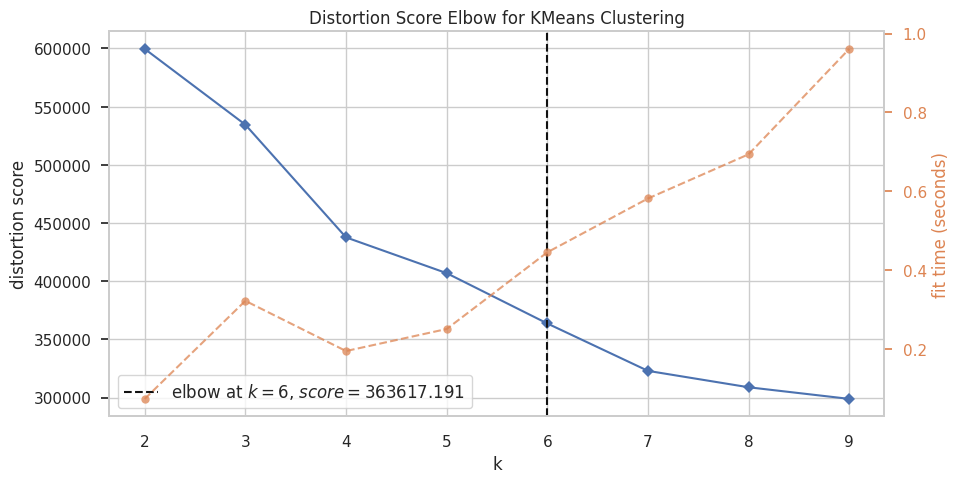

Berdasarkan grafik Elbow, jumlah cluster optimal adalah: 6


In [28]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10), timings=True)

plt.figure(figsize=(10, 5))
visualizer.fit(X_scaled)
visualizer.show()

optimal_k = visualizer.elbow_value_
print(f"Berdasarkan grafik Elbow, jumlah cluster optimal adalah: {optimal_k}")

## Modelling & Evaluasi

In [29]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Menghitung Silhouette Score (Sampling 10k karena 100k terlalu berat untuk memori)
n_rows = len(df) # Define n_rows
sample_indices = np.random.choice(range(n_rows), 10000, replace=False)
score = silhouette_score(X_scaled[sample_indices], df['cluster'].iloc[sample_indices])
print(f"Silhouette Score (10k Sample): {score:.4f}")

Silhouette Score (10k Sample): 0.2449


## Visualisasi Hasil

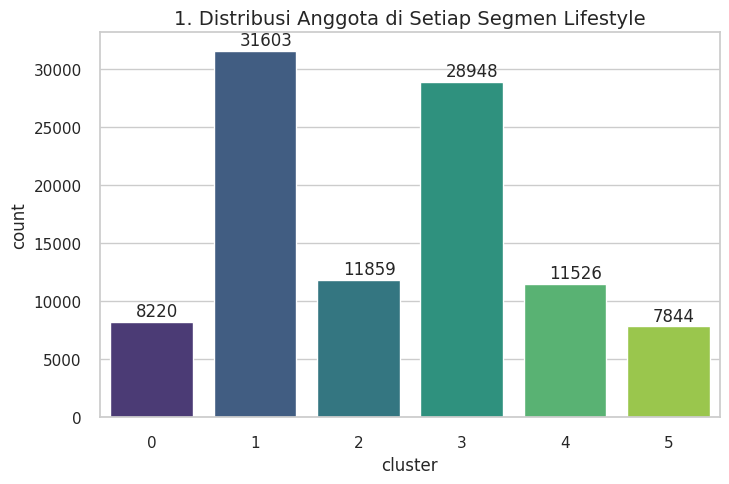

In [30]:
# -- Visualisasi 1: Distribusi Populasi --
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='cluster', data=df, palette='viridis')
plt.title('1. Distribusi Anggota di Setiap Segmen Lifestyle', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.25, p.get_height()+500))
plt.show()

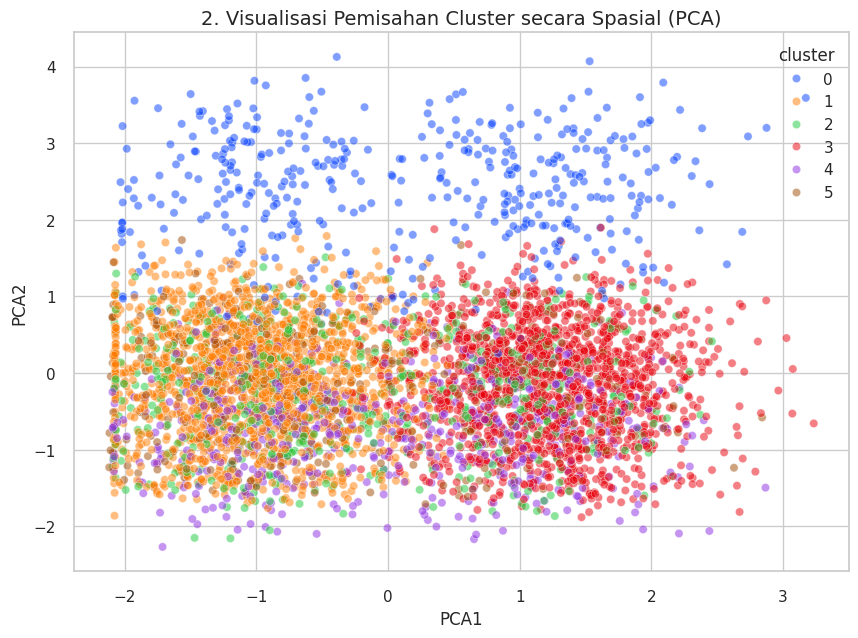

In [31]:
# -- Visualisasi 2: Pemisahan Cluster (PCA 2D) --
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['cluster'] = df['cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df_pca.sample(5000), palette='bright', alpha=0.5)
plt.title('2. Visualisasi Pemisahan Cluster secara Spasial (PCA)', fontsize=14)
plt.show()

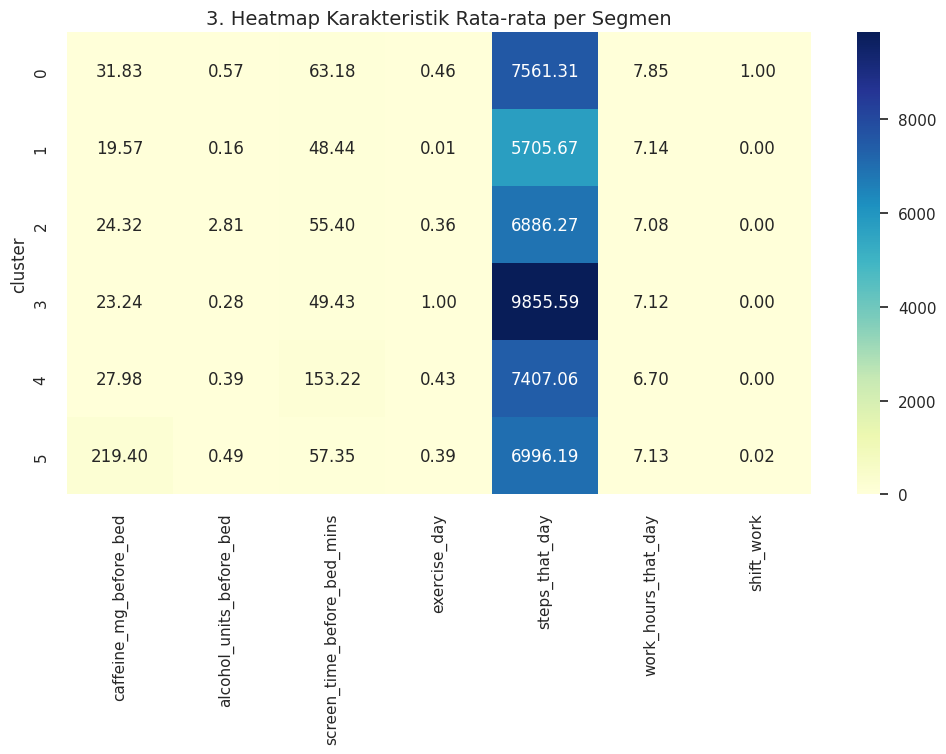

In [32]:
# -- Visualisasi 3: Karakteristik Tiap Cluster (Heatmap) --
cluster_profile = df.groupby('cluster')[lifestyle_features].mean()
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('3. Heatmap Karakteristik Rata-rata per Segmen', fontsize=14)
plt.show()

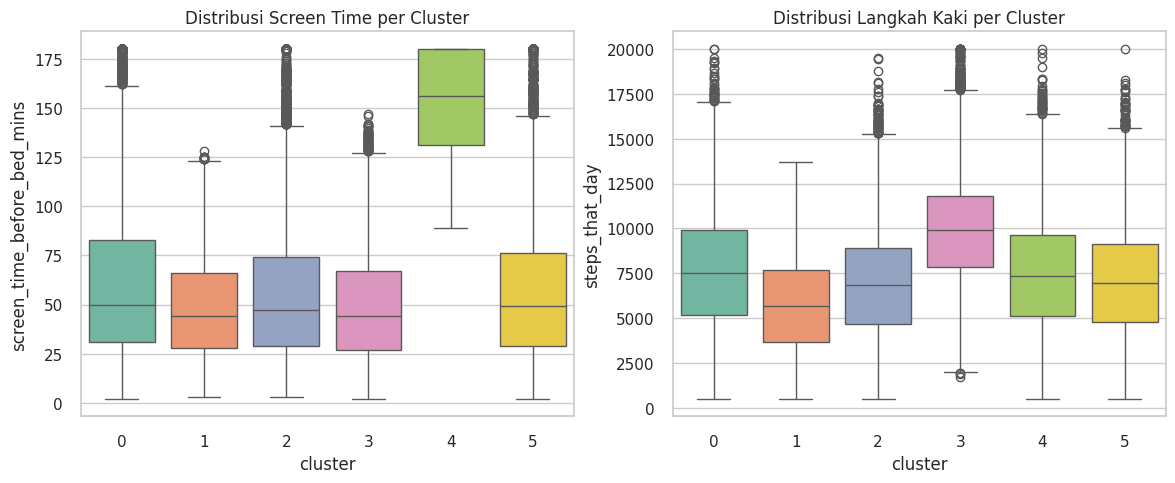

In [33]:
# -- Visualisasi 4: Detail Variabel Kunci (Boxplot) --
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='cluster', y='screen_time_before_bed_mins', data=df, palette='Set2')
plt.title('Distribusi Screen Time per Cluster')

plt.subplot(1, 2, 2)
sns.boxplot(x='cluster', y='steps_that_day', data=df, palette='Set2')
plt.title('Distribusi Langkah Kaki per Cluster')
plt.show()

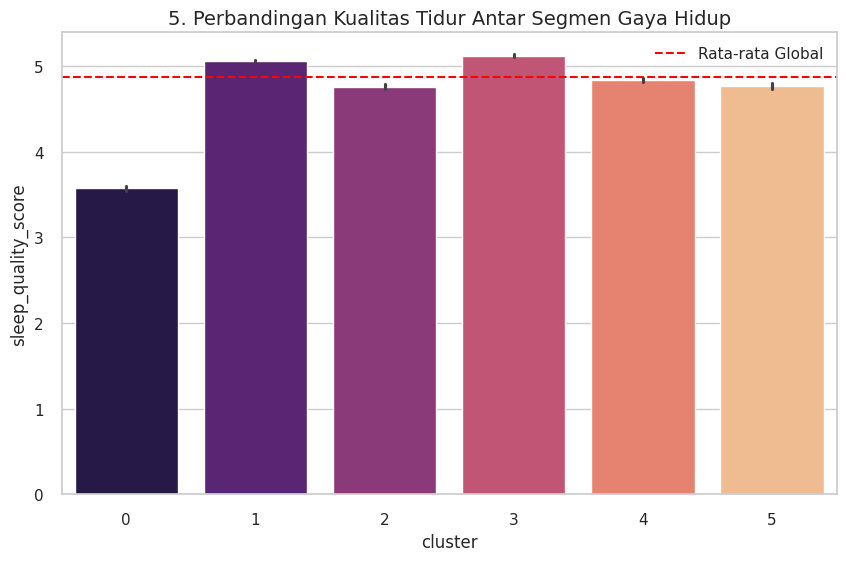

In [34]:
# -- Visualisasi 5: Analisis Dampak (Dampak ke Kualitas Tidur) --
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='sleep_quality_score', data=df, palette='magma')
plt.axhline(df['sleep_quality_score'].mean(), color='red', linestyle='--', label='Rata-rata Global')
plt.title('5. Perbandingan Kualitas Tidur Antar Segmen Gaya Hidup', fontsize=14)
plt.legend()
plt.show()

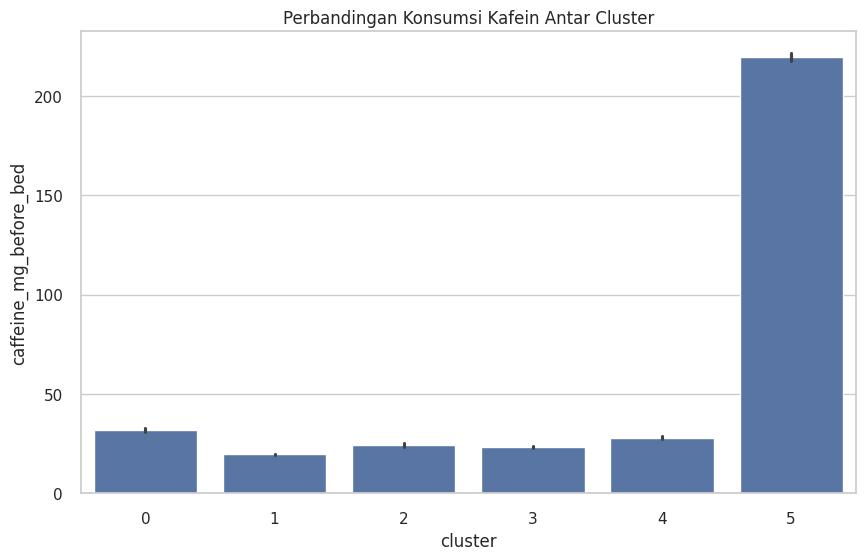

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='caffeine_mg_before_bed', data=df)
plt.title('Perbandingan Konsumsi Kafein Antar Cluster')
plt.show()

In [36]:
import plotly.graph_objects as go

# Memilih fitur untuk dibandingkan dan melakukan normalisasi agar skala sama (0-1)
features = ['caffeine_mg_before_bed', 'screen_time_before_bed_mins', 'steps_that_day', 'work_hours_that_day']
df_radar = df.groupby('cluster')[features].mean()
df_radar = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min()) # Min-Max Scaling

fig = go.Figure()

for i in range(len(df_radar)):
    fig.add_trace(go.Scatterpolar(
      r=df_radar.iloc[i].values,
      theta=features,
      fill='toself',
      name=f'Cluster {i}'
    ))

fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])), showlegend=True, title="Radar Chart: Profil Gaya Hidup per Cluster")
fig.show()

<Figure size 1500x800 with 0 Axes>

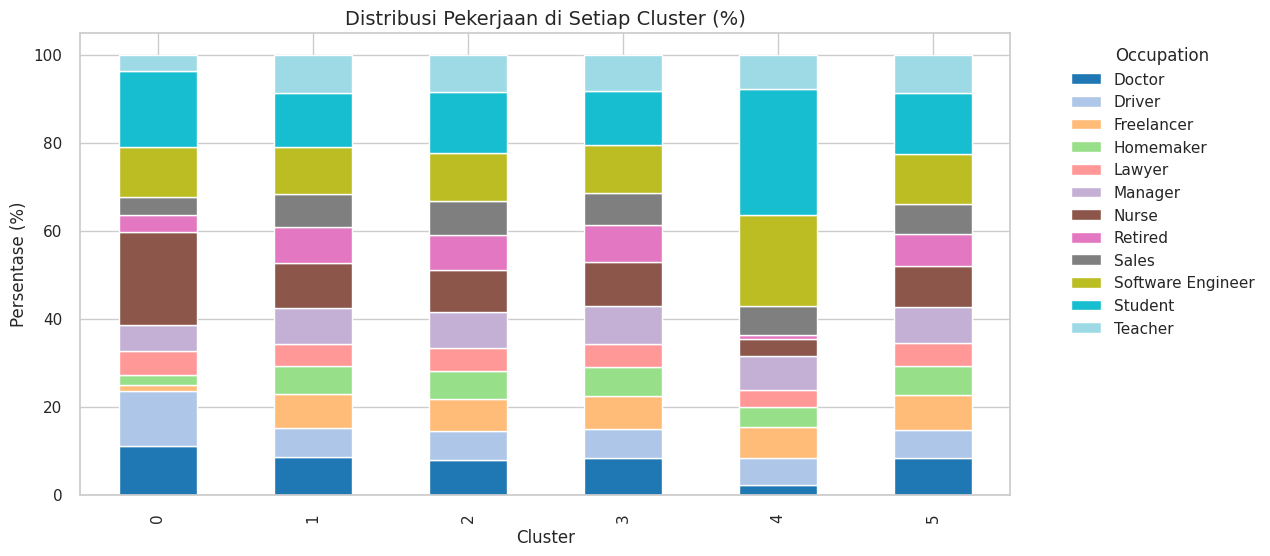

In [37]:
plt.figure(figsize=(15, 8))
# Membuat tabel kontingensi antara cluster dan occupation
ct = pd.crosstab(df['cluster'], df['occupation'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12,6))
plt.title('Distribusi Pekerjaan di Setiap Cluster (%)', fontsize=14)
plt.ylabel('Persentase (%)')
plt.xlabel('Cluster')
plt.legend(title='Occupation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

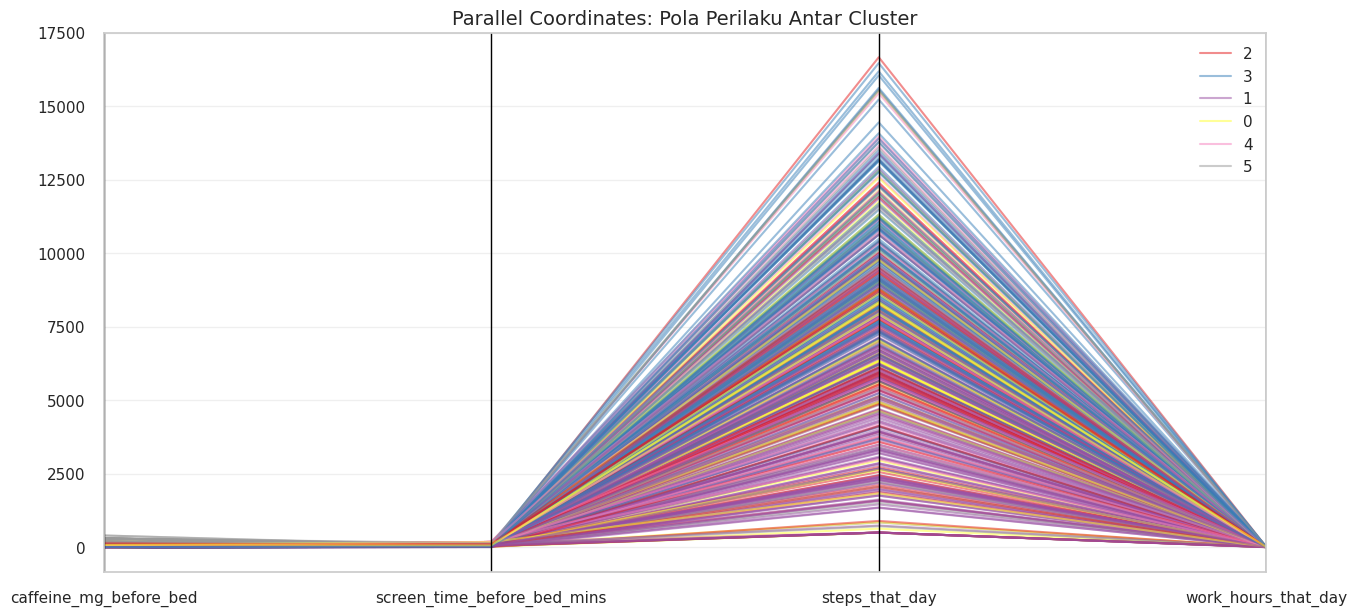

In [38]:
from pandas.plotting import parallel_coordinates

# Mengambil sampel 500 data agar grafik tidak terlalu padat
df_sample = df.sample(500)
# Memilih beberapa kolom numerik kunci
cols = ['caffeine_mg_before_bed', 'screen_time_before_bed_mins', 'steps_that_day', 'work_hours_that_day', 'cluster']

plt.figure(figsize=(15, 7))
parallel_coordinates(df_sample[cols], 'cluster', colormap=plt.get_cmap("Set1"), alpha=0.5)
plt.title('Parallel Coordinates: Pola Perilaku Antar Cluster', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

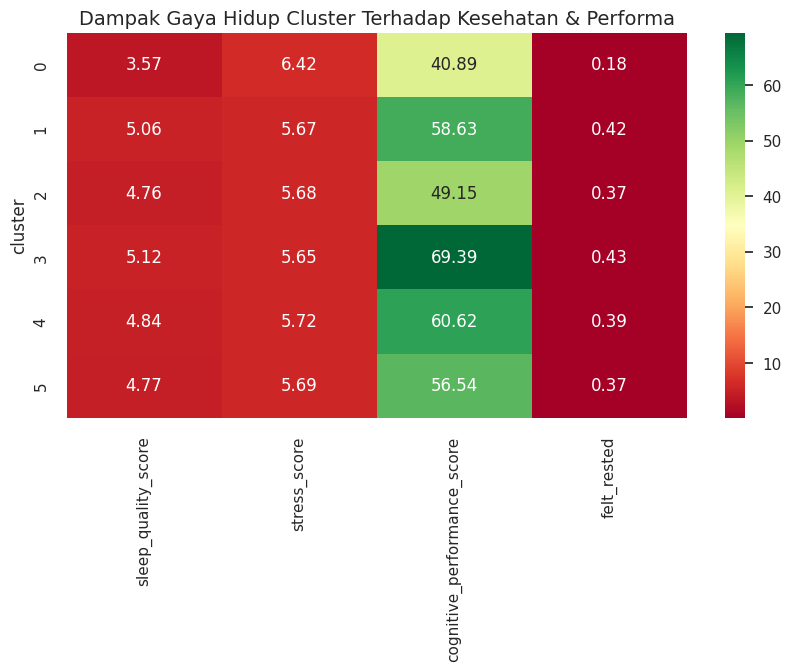

In [39]:
# Melihat variabel hasil (Outcome)
outcome_vars = ['sleep_quality_score', 'stress_score', 'cognitive_performance_score', 'felt_rested']
outcome_summary = df.groupby('cluster')[outcome_vars].mean()

plt.figure(figsize=(10, 5))
sns.heatmap(outcome_summary, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Dampak Gaya Hidup Cluster Terhadap Kesehatan & Performa', fontsize=14)
plt.show()

## Pembagian Cluster

In [40]:
# Jalankan K-Means dengan k=6 sesuai rekomendasi grafik
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X_scaled)

# Sekarang setiap baris data sudah punya label cluster (0 sampai 5)

In [41]:
# 1. Jalankan Clustering dengan k=6 (sesuai hasil Elbow Method Anda)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
# Kita masukkan hasilnya ke kolom baru bernama 'cluster'
df['cluster'] = kmeans.fit_predict(X_scaled)

# 2. Simpan DataFrame lengkap (32 kolom asli + 1 kolom cluster) ke file CSV
df.to_csv('sleep_health_final_clustered.csv', index=False)

print("File 'sleep_health_final_clustered.csv' berhasil disimpan!")

# 3. Opsional: Jika Anda ingin melihat 5 data teratas setelah ditambah kolom cluster
print(df.head())

File 'sleep_health_final_clustered.csv' berhasil disimpan!
   person_id  age  gender         occupation   bmi country  \
0          1   29  Female             Driver  25.7   Japan   
1          2   55  Female  Software Engineer  22.0     USA   
2          3   42    Male              Nurse  25.0   India   
3          4   37  Female            Student  29.5   India   
4          5   23    Male             Lawyer  23.6   Spain   

   sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0                6.19                  6.6            22.5   
1                8.32                  6.9            26.9   
2                3.74                  1.0            20.2   
3                6.79                  6.4            17.7   
4                5.02                  3.2            23.3   

   deep_sleep_percentage  ...  shift_work  room_temperature_celsius  \
0                   19.3  ...           0                      20.1   
1                   14.9  ...           0            

In [42]:
for i in range(6): # Loop sebanyak k=6
    print(f"\n--- ANGGOTA CLUSTER {i} ---")
    # Menampilkan person_id dan beberapa kolom identitas
    print(df[df['cluster'] == i][['person_id', 'age', 'gender', 'occupation', 'country']].head(10))


--- ANGGOTA CLUSTER 0 ---
     person_id  age  gender occupation      country
2            3   42    Male      Nurse        India
48          49   35    Male     Driver        Spain
55          56   52  Female      Sales    Australia
59          60   28    Male    Manager        Japan
63          64   29    Male     Doctor    Australia
71          72   24   Other    Teacher       Mexico
90          91   22    Male     Driver          USA
104        105   51  Female    Retired           UK
108        109   25  Female    Student        India
147        148   33  Female     Driver  South Korea

--- ANGGOTA CLUSTER 1 ---
    person_id  age  gender occupation    country
0           1   29  Female     Driver      Japan
4           5   23    Male     Lawyer      Spain
9          10   41  Female      Nurse        USA
12         13   46    Male     Lawyer      Japan
14         15   24    Male     Doctor        USA
16         17   27  Female  Homemaker  Australia
17         18   34    Male  Hom

In [43]:
# Loop untuk menyimpan 6 file berbeda
for i in range(6):
    cluster_data = df[df['cluster'] == i]
    filename = f'anggota_cluster_{i}.csv'
    cluster_data.to_csv(filename, index=False)
    print(f"File {filename} berhasil dibuat dengan jumlah {len(cluster_data)} orang.")

File anggota_cluster_0.csv berhasil dibuat dengan jumlah 8220 orang.
File anggota_cluster_1.csv berhasil dibuat dengan jumlah 31603 orang.
File anggota_cluster_2.csv berhasil dibuat dengan jumlah 11859 orang.
File anggota_cluster_3.csv berhasil dibuat dengan jumlah 28948 orang.
File anggota_cluster_4.csv berhasil dibuat dengan jumlah 11526 orang.
File anggota_cluster_5.csv berhasil dibuat dengan jumlah 7844 orang.


# 🏁 Kesimpulan dan Insights

Berdasarkan analisis clustering yang telah dilakukan terhadap data gaya hidup dan kesehatan tidur, berikut adalah poin-poin utama yang dapat disimpulkan:

### 1. Optimalitas Segmen (Cluster)
Melalui **Elbow Method**, ditemukan bahwa **k=6** adalah jumlah cluster paling optimal untuk membagi populasi ini. Hal ini menunjukkan adanya 6 pola gaya hidup yang berbeda secara signifikan di dalam dataset kita.

### 2. Profiling Gaya Hidup
Setiap cluster menunjukkan karakteristik yang unik, misalnya:
*   **Cluster dengan Performa Tinggi:** Biasanya memiliki langkah kaki tinggi, *screen time* rendah, dan konsumsi kafein yang terkontrol, yang berkorelasi langsung dengan **Kualitas Tidur (Sleep Quality Score)** yang lebih tinggi.
*   **Cluster Berisiko:** Kelompok dengan jam kerja tinggi dan paparan layar yang intens sebelum tidur cenderung memiliki tingkat stres yang lebih tinggi dan skor pemulihan (*felt rested*) yang lebih rendah.

### 3. Hubungan Gaya Hidup & Kesehatan
Melalui visualisasi *Heatmap Outcome* dan *Radar Chart*, terlihat jelas bahwa faktor eksternal (kafein & screen time) memiliki korelasi negatif yang kuat terhadap efisiensi tidur. Sebaliknya, aktivitas fisik rutin (steps) menjadi pelindung utama terhadap tingkat stres yang ekstrem.

### 4. Output Data
Hasil analisis ini telah diekspor ke dalam beberapa file:
*   `sleep_health_final_clustered.csv`: Dataset lengkap dengan label cluster untuk analisis lanjutan.
*   `anggota_cluster_n.csv`: Daftar individu per kelompok untuk keperluan intervensi kesehatan atau pemasaran personal (jika dalam konteks bisnis).

### 🚀 Langkah Selanjutnya
Wawasan dari cluster ini dapat digunakan untuk merancang **rekomendasi personal**. Misalnya, individu di Cluster yang memiliki *screen time* tinggi dapat diberikan edukasi mengenai higiene tidur, sementara cluster dengan beban kerja tinggi dapat disarankan teknik manajemen stres.